# Etudes analytiques de 5 problèmes / 3 algotithmes

## Analyse d'une run, de plusieurs runs et de l'agrégation des runs

--- Menu d'analyse BBOB Algorithme ---
[1] : G3PCX
[2] : Randomsearch-5
[3] : STEPif

Quel algorithme veux-tu utiliser pour l'analyse ? (Tape le chiffre) : 3

--- Menu d'analyse BBOB Problème---
[1] : f2
[2] : f8
[3] : f10
[4] : f15
[5] : f21

Quel problème veux-tu analyser ? (Tape le chiffre) : 2

Analyse du problème f8 avec l'algorithme STEPif en cours...
ETAPE 1 : Visualiser et analyser l’exécution d’un run (une instance)
--- RUN 1 ---
      evals   f_minus_fopt  best_f_minus_fopt            fit      best_fit  \
0       1.0   72439.946780       72439.946780   72589.096780  72589.096780   
1       2.0   88085.709620       72439.946780   88234.859620  72589.096780   
2       3.0   72439.946780       72439.946780   72589.096780  72589.096780   
3       4.0  186458.386000       72439.946780  186607.536000  72589.096780   
4       5.0   83923.802480       72439.946780   84072.952480  72589.096780   
..      ...            ...                ...            ...           ...   
84  63095.0

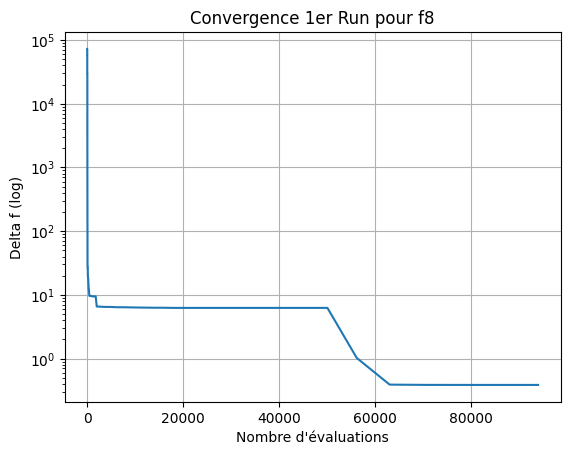

ETAPE 2 : Visualiser et analyser l’exécution de plusieurs runs (instances)
--- Toutes es runs ---
      evals   f_minus_fopt  best_f_minus_fopt  run
0         1   72439.946780       72439.946780    1
1         2   88085.709620       72439.946780    1
2         3   72439.946780       72439.946780    1
3         4  186458.386000       72439.946780    1
4         5   83923.802480       72439.946780    1
...     ...            ...                ...  ...
1329  63095      52.926769           0.157813   15
1330  70794       0.964287           0.157813   15
1331  79432      60.409818           0.157813   15
1332  89125       0.045315           0.040305   15
1333  91007       0.042331           0.040077   15

[1334 rows x 4 columns]


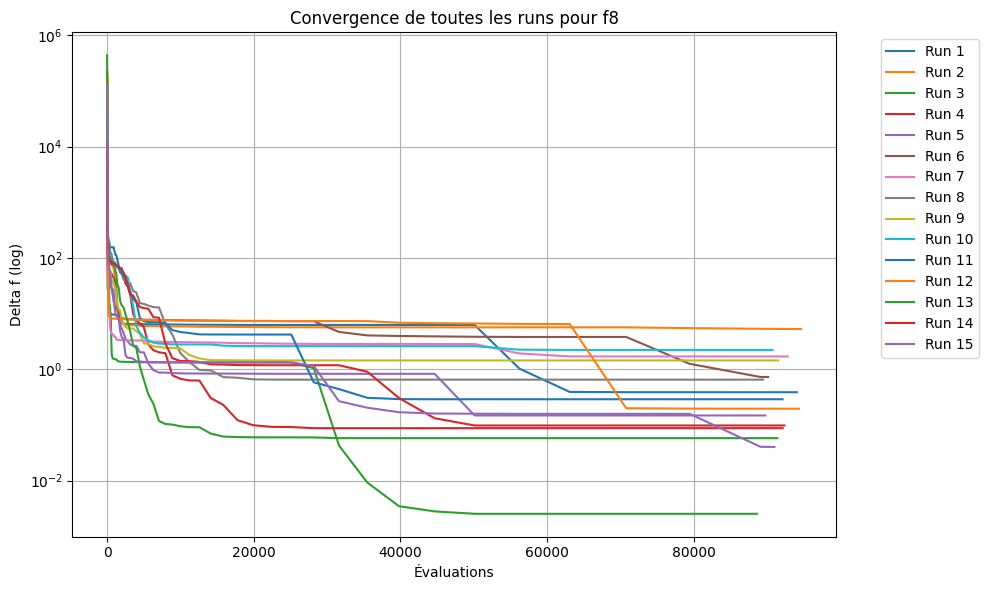

run              1              2              3              4   \
evals                                                              
1      72439.946780  235998.217600  189681.268400  211436.345300   
2      72439.946780   25620.357500  189681.268400  211436.345300   
3      72439.946780   25620.357500  189681.268400  211436.345300   
4      72439.946780   25620.357500  189681.268400  211436.345300   
5      72439.946780   25620.357500  161672.112700  211436.345300   
...             ...            ...            ...            ...   
92390      0.386124       5.322776       0.002523       0.087238   
92828      0.386124       5.322776       0.002523       0.087238   
94064      0.386124       5.322776       0.002523       0.087238   
94364      0.386124       5.322776       0.002523       0.087238   
94636      0.386124       5.259124       0.002523       0.087238   

run              5            6             7             8              9   \
evals                               

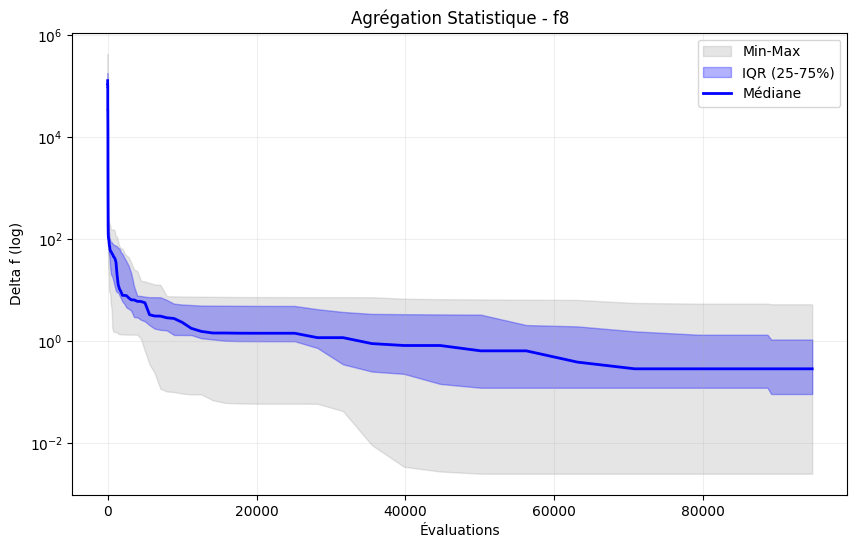

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

problemes = {
    "1": "f2",
    "2": "f8",
    "3": "f10",
    "4": "f15",
    "5": "f21",
}

algorithmes = {
    "1": "G3PCX",
    "2": "Randomsearch-5",
    "3": "STEPif",
}

print("--- Menu d'analyse BBOB Algorithme ---")
for touche, nom in algorithmes.items():
    print(f"[{touche}] : {nom}")

choix_algo = input("\nQuel algorithme veux-tu utiliser pour l'analyse ? (Tape le chiffre) : ")

print("\n--- Menu d'analyse BBOB Problème---")
for touche, nom in problemes.items():
    print(f"[{touche}] : {nom}")

choix_probleme = input("\nQuel problème veux-tu analyser ? (Tape le chiffre) : ")

if choix_algo in algorithmes:
    nom_algo = algorithmes[choix_algo]

    if "Randomsearch" in nom_algo:
        particularite_nom_f = "_i1"
    else:
        particularite_nom_f = ""

    if choix_probleme in problemes:
        nom_f = problemes[choix_probleme]

        print(f"\nAnalyse du problème {nom_f} avec l'algorithme {nom_algo} en cours...")

        # ETAPE 1 : Visualisation de l’exécution d’un run (une instance)

        print("ETAPE 1 : Visualisation de l’exécution d’un run (une instance)")
        donnee_run1 = []
        with open(f'{nom_algo}_bbobexp_{nom_f}_DIM10{particularite_nom_f}.tdat', 'r') as f:
            for ligne in f:
                if ligne[0] != '%':
                    donnee_run1.append(list(map(float, ligne.split())))
                elif len(donnee_run1) > 0:
                    break

        colonnes = ['evals', 'f_minus_fopt', 'best_f_minus_fopt', 'fit', 'best_fit'] + [f'x{i}' for i in range(1, 11)]
        df_run1 = pd.DataFrame(donnee_run1, columns=colonnes)

        print(f"--- RUN 1 ---")
        print(df_run1)

        plt.semilogy(df_run1['evals'], df_run1['best_f_minus_fopt'])
        plt.xlabel('Nombre d\'évaluations')
        plt.ylabel('Delta f (log)')
        plt.title(f'Convergence 1er Run pour {nom_f}')
        plt.grid(True)

        # Sauvegarde de l'étape 1
        plt.savefig(f"convergence_{nom_f}_run1_{nom_algo}.png", dpi=300, bbox_inches='tight')
        plt.show()

        # ETAPE 2 : Visualisation de l’exécution de plusieurs runs (instances)

        print("ETAPE 2 : Visualisation de l’exécution de plusieurs runs (instances)")

        cols = ['evals', 'f_minus_fopt', 'best_f_minus_fopt']
        df = pd.read_csv(f"{nom_algo}_bbobexp_{nom_f}_DIM10{particularite_nom_f}.tdat", sep=r'\s+', comment='%', names=cols, usecols=[0,1,2])
        df['run'] = (df['evals'] == 1).cumsum()

        print(f"--- Toutes es runs ---")
        print(df)

        plt.figure(figsize=(10, 6))
        for run_id, data in df.groupby('run'):
            plt.semilogy(data['evals'], data['best_f_minus_fopt'], label=f'Run {run_id}')

        plt.xlabel('Évaluations')
        plt.ylabel('Delta f (log)')
        plt.title(f'Convergence de toutes les runs pour {nom_f}')
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()

        # Sauvegarde de l'étape 2
        plt.savefig(f"convergence_{nom_f}_multirun_{nom_algo}.png", dpi=300, bbox_inches='tight')
        plt.show()

        # ETAPE 3 : Visualisation de l'agrégation (des runs/instances)

        data_pivot = df.pivot(index='evals', columns='run', values='best_f_minus_fopt').ffill()

        print(data_pivot)

        stats = pd.DataFrame(index=data_pivot.index)
        stats['median'] = data_pivot.median(axis=1)
        stats['q1'] = data_pivot.quantile(0.25, axis=1)
        stats['q3'] = data_pivot.quantile(0.75, axis=1)
        stats['min'] = data_pivot.min(axis=1)
        stats['max'] = data_pivot.max(axis=1)

        plt.figure(figsize=(10, 6))
        plt.fill_between(stats.index, stats['min'], stats['max'], color='gray', alpha=0.2, label='Min-Max')
        plt.fill_between(stats.index, stats['q1'], stats['q3'], color='blue', alpha=0.3, label='IQR (25-75%)')
        plt.semilogy(stats.index, stats['median'], color='blue', linewidth=2, label='Médiane')

        print("ETAPE 3 : Visualisation de l'agrégation (des runs/instances)")
        plt.xlabel('Évaluations')
        plt.ylabel('Delta f (log)')
        plt.title(f'Agrégation Statistique - {nom_f}')
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.legend()

        # Sauvegarde de l'étape 3
        plt.savefig(f"aggregation_graphique_{nom_f}_{nom_algo}.png", dpi=300, bbox_inches='tight')
        plt.show()

    else:
        print("Erreur : Choix du problème invalide.")
else :
    print("Erreur : Choix de l'algorithme invalide.")

## Comparaison entre les 3 algorithmes

--- Comparaison des 3 algoritmes ---
[1] : f2
[2] : f8
[3] : f10
[4] : f15
[5] : f21

Sur quel problème veux-tu comparer les 3 algorithmes ? : 5


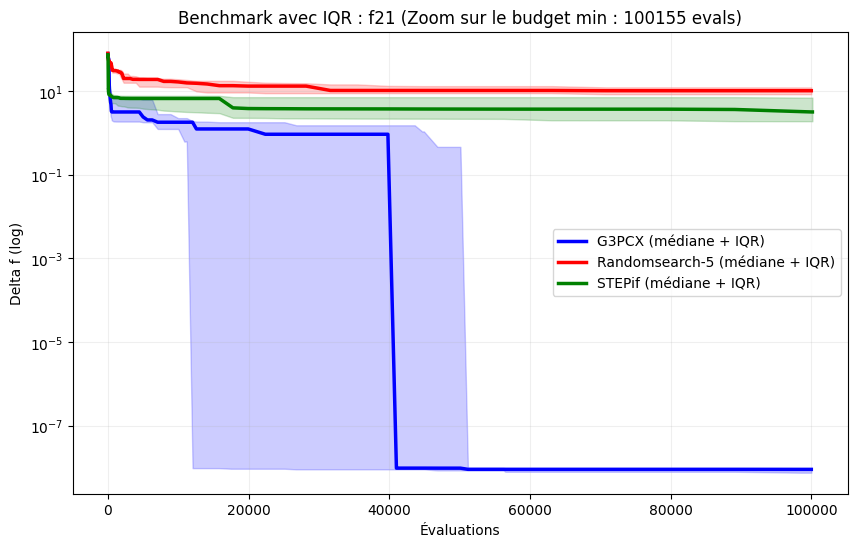

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

problemes = {"1": "f2",
             "2": "f8",
             "3": "f10",
             "4": "f15",
             "5": "f21"}

algorithmes = ["G3PCX",
               "Randomsearch-5",
               "STEPif"]

couleurs = {"G3PCX": "blue",
            "Randomsearch-5": "red",
            "STEPif": "green"}

print("--- Comparaison des 3 algoritmes ---")
for touche, nom in problemes.items():
    print(f"[{touche}] : {nom}")

choix = input("\nSur quel problème veux-tu comparer les 3 algorithmes ? : ")

if choix in problemes:
    nom_f = problemes[choix]
    plt.figure(figsize=(10, 6))

    medians = {}
    q1_medians = {}
    q3_medians = {}
    max_evals = []

    for algo in algorithmes:
        if "Randomsearch" in algo:
            part = "_i1"
        else :
            part = ""
        chemin = f"{algo}_bbobexp_{nom_f}_DIM10{part}.tdat"

        cols = ['evals', 'f_minus_fopt', 'best_f_minus_fopt']
        df_temp = pd.read_csv(chemin, sep=r'\s+', comment='%', names=cols, usecols=[0,1,2])
        max_evals.append(df_temp['evals'].max())

        df_temp['run'] = (df_temp['evals'] == 1).cumsum()
        pivot = df_temp.pivot(index='evals', columns='run', values='best_f_minus_fopt').ffill()

        medians[algo] = pivot.median(axis=1)
        q1_medians[algo] = pivot.quantile(0.25, axis=1)
        q3_medians[algo] = pivot.quantile(0.75, axis=1)

    limite_x = min(max_evals)

    for algo in algorithmes:
      m = medians[algo][medians[algo].index <= limite_x]
      low = q1_medians[algo][q1_medians[algo].index <= limite_x]
      high = q3_medians[algo][q3_medians[algo].index <= limite_x]

      plt.fill_between(m.index, low, high,color=couleurs[algo], alpha=0.2)
      plt.semilogy(m.index, m.values,
                     label=f"{algo} (médiane + IQR)", color=couleurs[algo], linewidth=2.5)

    plt.xlabel('Évaluations')
    plt.ylabel('Delta f (log)')
    plt.title(f'Benchmark avec IQR : {nom_f} (Zoom sur le budget min : {int(limite_x)} evals)')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()

    nom_image = f"benchmark_{nom_f}_DIM10.png"
    plt.savefig(nom_image, dpi=300, bbox_inches='tight')
    plt.show()